Database connected successfully!
Available Tables:
              name
0   aircrafts_data
1    airports_data
2  boarding_passes
3         bookings
4          flights
5            seats
6   ticket_flights
7          tickets
Dataset Sizes:
Flights        : (33121, 10)
Ticket Flights : (1045726, 4)
Bookings       : (262788, 3)
Tickets        : (366733, 3)
Airports       : (104, 5)
FLIGHTS DATA:
   flight_id flight_no     scheduled_departure       scheduled_arrival  \
0       1185    PG0134  2017-09-10 09:50:00+03  2017-09-10 14:55:00+03   
1       3979    PG0052  2017-08-25 14:50:00+03  2017-08-25 17:35:00+03   
2       4739    PG0561  2017-09-05 12:30:00+03  2017-09-05 14:15:00+03   
3       5502    PG0529  2017-09-12 09:50:00+03  2017-09-12 11:20:00+03   
4       6938    PG0461  2017-09-04 12:25:00+03  2017-09-04 13:20:00+03   

  departure_airport arrival_airport     status aircraft_code actual_departure  \
0               DME             BTK  Scheduled           319               \N   

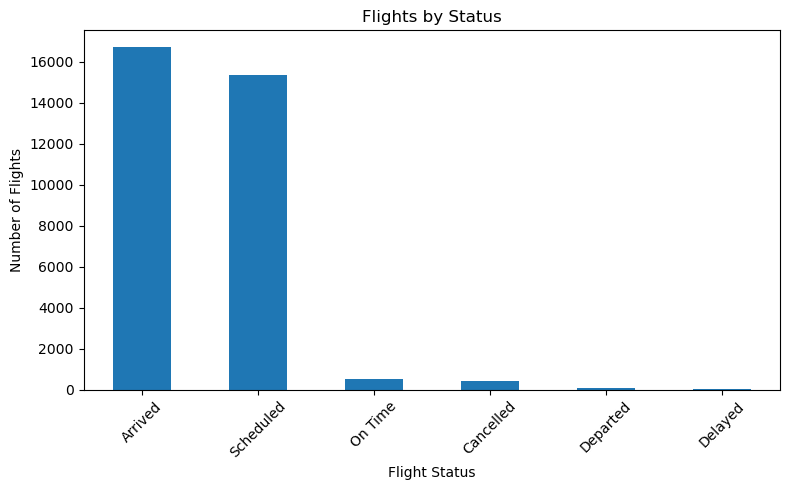

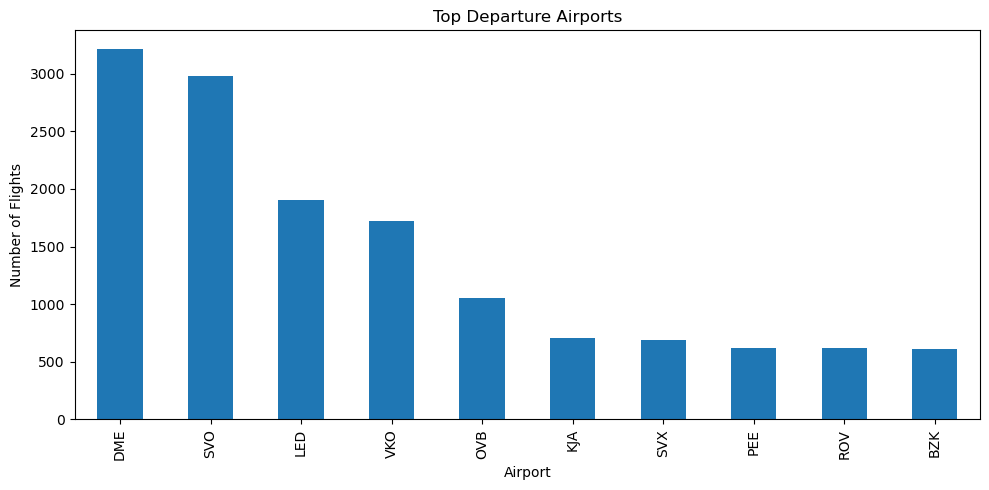

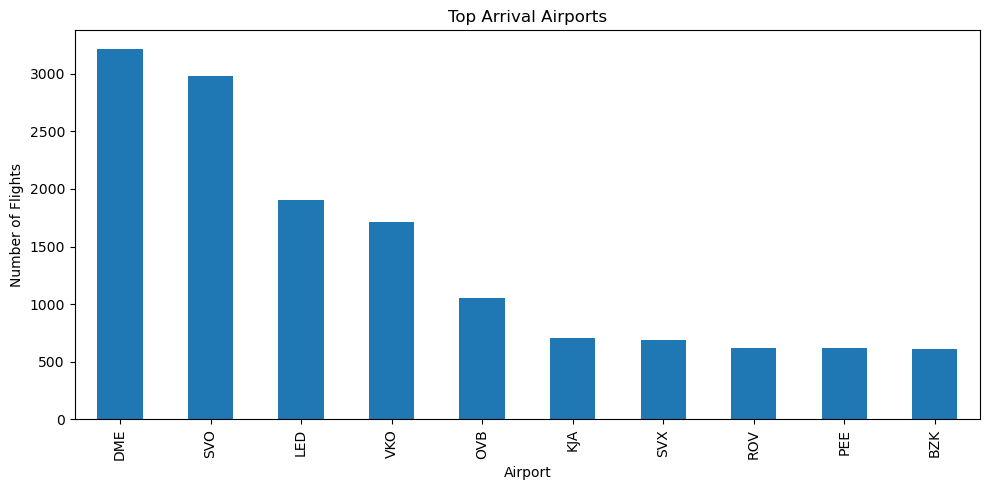

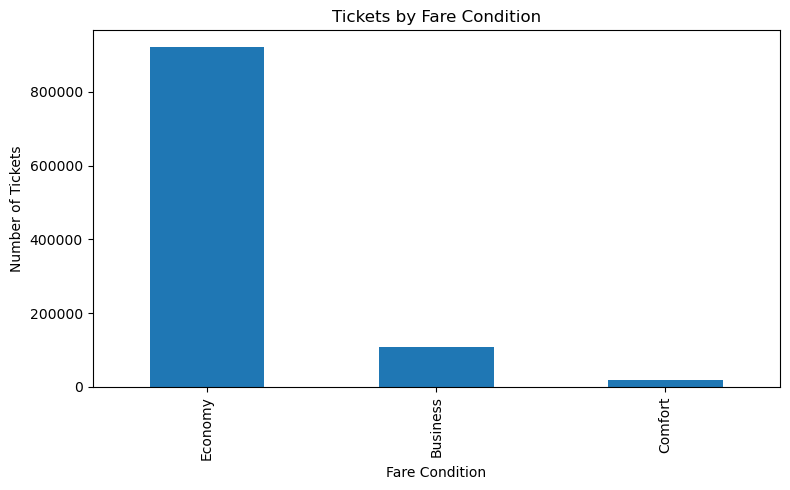

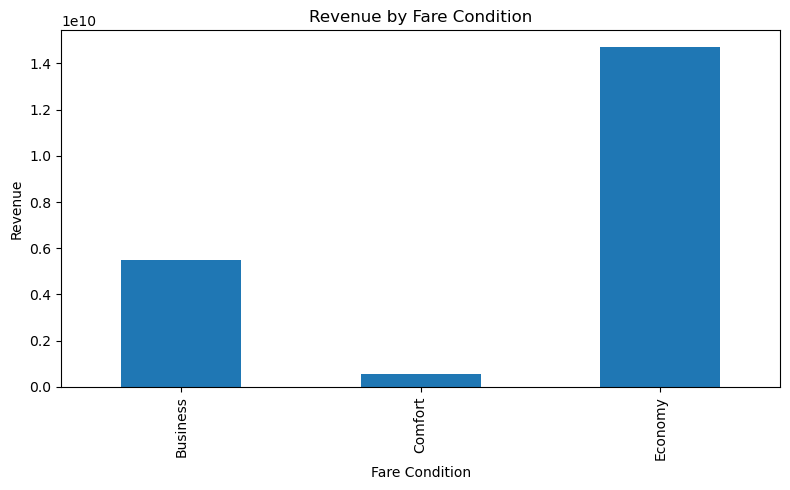

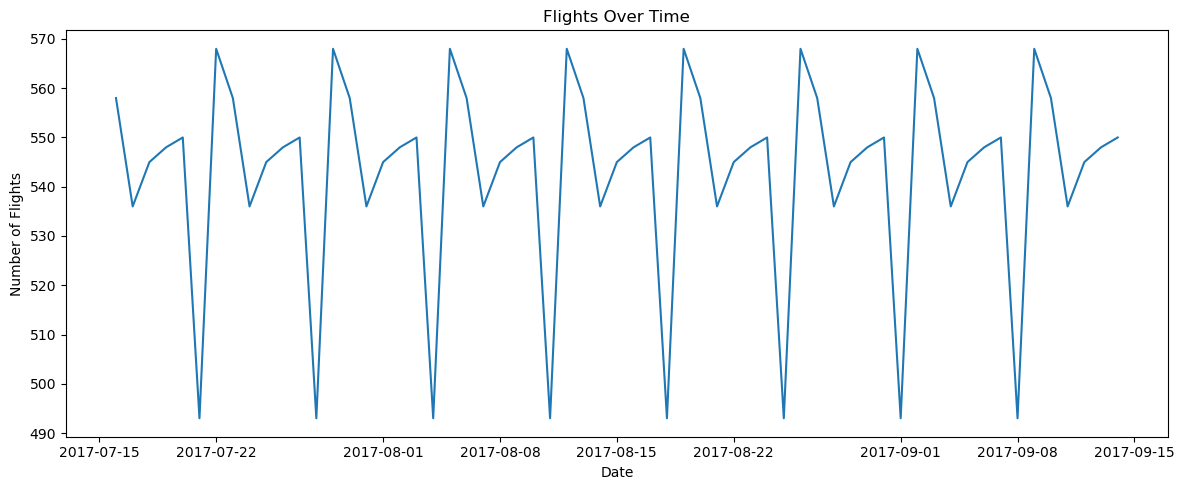

Airport Information:
   airport_code                                       airport_name  \
0           YKS          {"en": "Yakutsk Airport", "ru": "Якутск"}   
1           MJZ            {"en": "Mirny Airport", "ru": "Мирный"}   
2           KHV  {"en": "Khabarovsk-Novy Airport", "ru": "Хабар...   
3           PKC        {"en": "Yelizovo Airport", "ru": "Елизово"}   
4           UUS  {"en": "Yuzhno-Sakhalinsk Airport", "ru": "Хом...   
5           VVO  {"en": "Vladivostok International Airport", "r...   
6           LED         {"en": "Pulkovo Airport", "ru": "Пулково"}   
7           KGD      {"en": "Khrabrovo Airport", "ru": "Храброво"}   
8           KEJ       {"en": "Kemerovo Airport", "ru": "Кемерово"}   
9           CEK  {"en": "Chelyabinsk Balandino Airport", "ru": ...   
10          MQF  {"en": "Magnitogorsk International Airport", "...   
11          PEE   {"en": "Bolshoye Savino Airport", "ru": "Пермь"}   
12          SGC           {"en": "Surgut Airport", "ru": "Сургут"}   

In [6]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. CONNECT TO DATABASE
conn = sqlite3.connect("C:/Users/intel/Downloads/travel.sqlite/travel.sqlite")
print("Database connected successfully!")

# 2. SHOW AVAILABLE TABLES
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table'
""", conn)

print("Available Tables:")
print(tables)

# 3. LOAD TABLES
flights = pd.read_sql(
    "SELECT * FROM flights",
    conn
)

ticket_flights = pd.read_sql(
    "SELECT * FROM ticket_flights",
    conn
)

bookings = pd.read_sql(
    "SELECT * FROM bookings",
    conn
)

tickets = pd.read_sql(
    "SELECT * FROM tickets",
    conn
)

airports = pd.read_sql(
    "SELECT * FROM airports_data",
    conn
)

print("Dataset Sizes:")
print("Flights        :", flights.shape)
print("Ticket Flights :", ticket_flights.shape)
print("Bookings       :", bookings.shape)
print("Tickets        :", tickets.shape)
print("Airports       :", airports.shape)

# 4. DISPLAY FIRST 5 ROWS
print("FLIGHTS DATA:")
print(flights.head())

print("TICKET FLIGHTS DATA:")
print(ticket_flights.head())

print("BOOKINGS DATA:")
print(bookings.head())

print("TICKETS DATA:")
print(tickets.head())

print("AIRPORTS DATA:")
print(airports.head())

# 5. CHECK DATA INFORMATION
print("Flights Information:")
flights.info()

# 6. CHECK MISSING VALUES
print("Missing Values in Flights:")
print(flights.isnull().sum())

# 7. STATISTICAL SUMMARY
print("Flight Statistical Summary:")
print(flights.describe())

# 8. SELECT IMPORTANT FLIGHT COLUMNS
flight_data = flights[
    [
        "flight_id",
        "flight_no",
        "scheduled_departure",
        "scheduled_arrival",
        "departure_airport",
        "arrival_airport",
        "status",
        "aircraft_code"
    ]
].copy()

# 9. CONVERT DATE COLUMNS
flight_data["scheduled_departure"] = pd.to_datetime(
    flight_data["scheduled_departure"],
    errors="coerce"
)

flight_data["scheduled_arrival"] = pd.to_datetime(
    flight_data["scheduled_arrival"],
    errors="coerce"
)

# 10. CHECK DUPLICATES
print(
    "Duplicate Flight Records:",
    flight_data.duplicated().sum()
)

# 11. CREATE DATE COLUMN
flight_data["date"] = (
    flight_data["scheduled_departure"].dt.date
)

# 12. FLIGHT STATUS ANALYSIS
status_count = flight_data["status"].value_counts()

print("Flights by Status:")
print(status_count)

# 13. DEPARTURE AIRPORT ANALYSIS
departure_count = (
    flight_data["departure_airport"]
    .value_counts()
    .head(10)
)

print("Top Departure Airports:")
print(departure_count)

# 14. ARRIVAL AIRPORT ANALYSIS
arrival_count = (
    flight_data["arrival_airport"]
    .value_counts()
    .head(10)
)

print("Top Arrival Airports:")
print(arrival_count)

# 15. FARE CONDITION ANALYSIS
fare_count = ticket_flights["fare_conditions"].value_counts()

print("Fare Conditions:")
print(fare_count)

# 16. REVENUE BY FARE CONDITION
revenue_fare = (
    ticket_flights
    .groupby("fare_conditions")["amount"]
    .sum()
)

print("Revenue by Fare Condition:")
print(revenue_fare)

# 17. KPI CALCULATIONS
total_flights = flights["flight_id"].count()
total_bookings = bookings["book_ref"].count()
total_tickets = tickets["ticket_no"].count()
total_revenue = ticket_flights["amount"].sum()
average_fare = ticket_flights["amount"].mean()
booking_revenue = bookings["total_amount"].sum()

print("AIRLINE KPIs")
print("Total Flights   :", total_flights)
print("Total Bookings  :", total_bookings)
print("Total Tickets   :", total_tickets)
print("Total Revenue   :", total_revenue)
print("Average Fare    :", round(average_fare, 2))
print("Booking Revenue :", booking_revenue)

# 18. FLIGHTS BY DATE
daily_flights = (
    flight_data
    .groupby("date")["flight_id"]
    .count()
)

print("Flights by Date:")
print(daily_flights.head(10))

# 19. FLIGHT STATUS PERCENTAGE
status_percentage = (
    flight_data["status"]
    .value_counts(normalize=True)
    * 100
)

print("Flight Status Percentage:")
print(status_percentage.round(2))

# 20. PLOT FLIGHTS BY STATUS
plt.figure(figsize=(8, 5))
status_count.plot(kind="bar")
plt.title("Flights by Status")
plt.xlabel("Flight Status")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 21. PLOT DEPARTURE AIRPORTS
plt.figure(figsize=(10, 5))
departure_count.plot(kind="bar")
plt.title("Top Departure Airports")
plt.xlabel("Airport")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.show()

# 22. PLOT ARRIVAL AIRPORTS
plt.figure(figsize=(10, 5))
arrival_count.plot(kind="bar")
plt.title("Top Arrival Airports")
plt.xlabel("Airport")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.show()

# 23. PLOT FARE CONDITIONS
plt.figure(figsize=(8, 5))
fare_count.plot(kind="bar")
plt.title("Tickets by Fare Condition")
plt.xlabel("Fare Condition")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

# 24. PLOT REVENUE BY FARE CONDITION
plt.figure(figsize=(8, 5))
revenue_fare.plot(kind="bar")
plt.title("Revenue by Fare Condition")
plt.xlabel("Fare Condition")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# 25. PLOT FLIGHTS OVER TIME
plt.figure(figsize=(12, 5))
daily_flights.plot(kind="line")
plt.title("Flights Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.show()

# 26. AIRPORT INFORMATION
print("Airport Information:")
print(
    airports[
        [
            "airport_code",
            "airport_name",
            "city",
            "timezone"
        ]
    ].head(20)
)

# 27. CREATE DASHBOARD-READY DATA
airline_dashboard = flight_data[
    [
        "flight_id",
        "flight_no",
        "scheduled_departure",
        "scheduled_arrival",
        "departure_airport",
        "arrival_airport",
        "status",
        "aircraft_code",
        "date"
    ]
].copy()

print("Dashboard Ready Data:")
print(airline_dashboard.head())

# 28. SAVE CLEANED CSV
airline_dashboard.to_csv(
    "Airline_Cleaned.csv",
    index=False
)

print("Airline_Cleaned.csv created!")

# 29. SAVE DATA TO EXCEL
with pd.ExcelWriter(
    "Airline_Data.xlsx",
    engine="openpyxl"
) as writer:
    flights.to_excel(
        writer,
        sheet_name="Flights",
        index=False
    )
    ticket_flights.to_excel(
        writer,
        sheet_name="Ticket_Flights",
        index=False
    )
    bookings.to_excel(
        writer,
        sheet_name="Bookings",
        index=False
    )
    tickets.to_excel(
        writer,
        sheet_name="Tickets",
        index=False
    )
    airports.to_excel(
        writer,
        sheet_name="Airports",
        index=False
    )

print("Airline_Data.xlsx created!")

# 30. CLOSE DATABASE
conn.close()
print("Database connection closed.")
print("AIRLINE ANALYSIS COMPLETED!")